In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import sys
sys.path.insert(0, "/zhome/71/c/146676/texture_tomography/maptools")
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
from datetime import datetime
from tqdm.notebook import tqdm

maptools.job.info()
maptools.plot.dark()
!which python
from scipy.ndimage import generic_filter
from scipy.optimize import curve_fit
from matplotlib.patches import FancyArrowPatch, Circle

from ImageD11 import cImageD11
from ImageD11.sinograms.roi_iradon import run_iradon, run_mlem
from scipy.ndimage import (
    gaussian_filter,
    median_filter,
    maximum_filter,
    binary_fill_holes,
)


from orix import plot
from orix.vector import Vector3d, Miller
from orix.quaternion.symmetry import Oh
from orix.quaternion import Orientation, symmetry
from orix.crystal_map import Phase

import time
import numba
import ImageD11.columnfile
import ImageD11.sinograms.dataset
import ImageD11.sinograms.geometry as geometry
import ImageD11.sinograms.point_by_point
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils

hostname: n-62-11-21
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 24
Memory available: 793.409933312 GB
~/miniconda3/envs/textom/bin/python


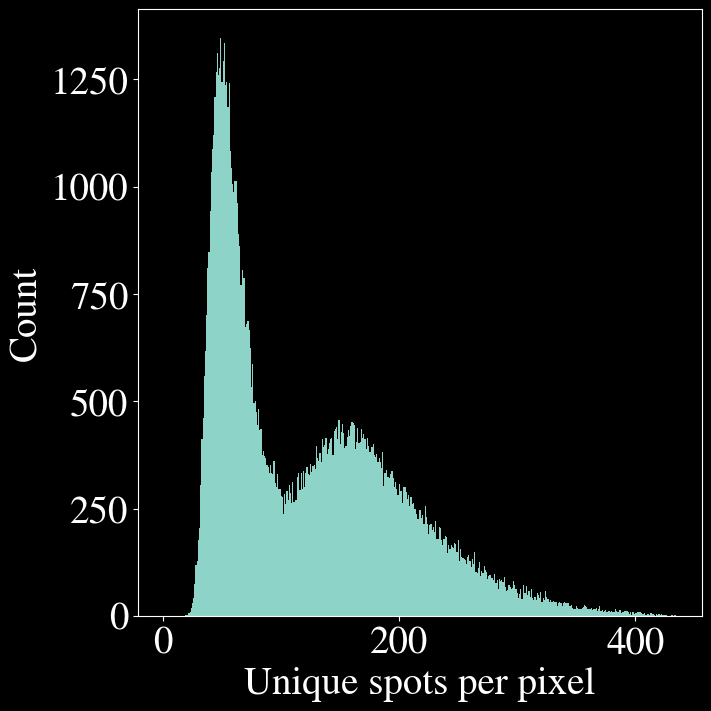

In [3]:
root = "/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/al1050_15pct_center_slice"
filetag = "medium_pks_18M_2026_0924_134307"
dset_path = os.path.join(root, filetag + "_dummy_dset.h5")
colf_path = os.path.join(root, filetag + "_colf.h5")

y0 = maptools.constants.ROTATION_AXIS_DTY_SHIFT
colf = ImageD11.columnfile.colfile_from_hdf(colf_path)
dset = maptools.dummy.load_dset(dset_path)
refined_pbpmap = pbp.PBPMap(dset.refoutfile)
refined_pbpmap.plot_nuniq_hist()

In [4]:
refined_pbpmap.choose_best(minpeaks=85)
m = ~np.isnan(refined_pbpmap.best_ubi[:, :, 0, 0])

In [5]:
dty = colf.dty
omega = colf.omega
whole_sample_sino, xedges, yedges = np.histogram2d(
    dty, omega, bins=[dset.ybinedges, dset.obinedges]
)
shift, _ = geometry.sino_shift_and_pad(
    y0, len(dset.ybincens), dset.ybincens.min(), dset.ystep
)
nthreads = cImageD11.cores_available()
# make sure the shape is the same as sx_grid
pad = m.shape[0] - whole_sample_sino.shape[0]

pad = m.shape[0] - whole_sample_sino.shape[0]

rec = run_mlem(
    whole_sample_sino,
    dset.obincens,
    mask=None,
    pad=pad,
    shift=shift,
    workers=10,
    niter=30,
    apply_halfmask=False,
    mask_central_zingers=False,
    central_mask_radius=25,
)

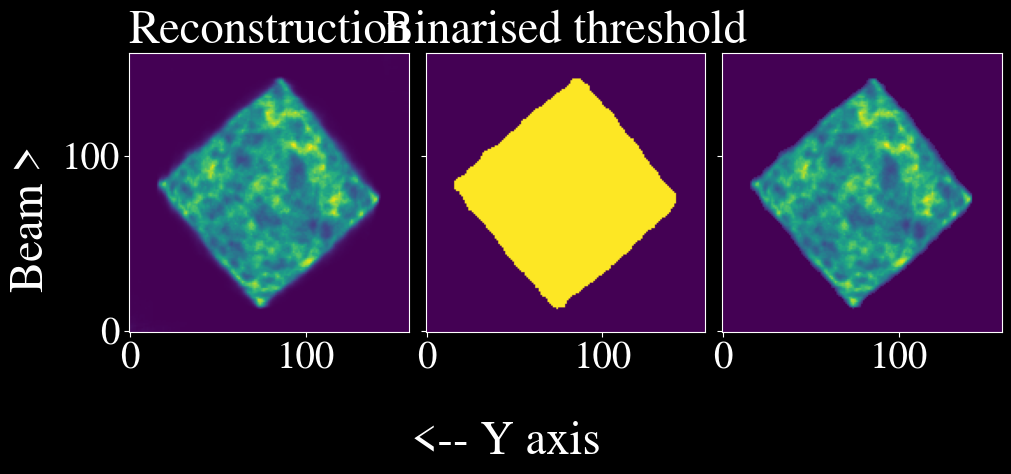

In [6]:
fig, axs = plt.subplots(
    1, 3, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 5)
)
axs[0].imshow(rec, origin="lower")

mm = rec.copy() / np.max(rec)
mm = mm > 0.1

axs[1].imshow(mm, origin="lower")
axs[0].set_title("Reconstruction")
axs[1].set_title("Binarised threshold")
axs[2].imshow(mm * rec, origin="lower")

fig.supxlabel("<-- Y axis")
fig.supylabel("Beam >")

plt.show()

In [7]:
m = mm.copy()

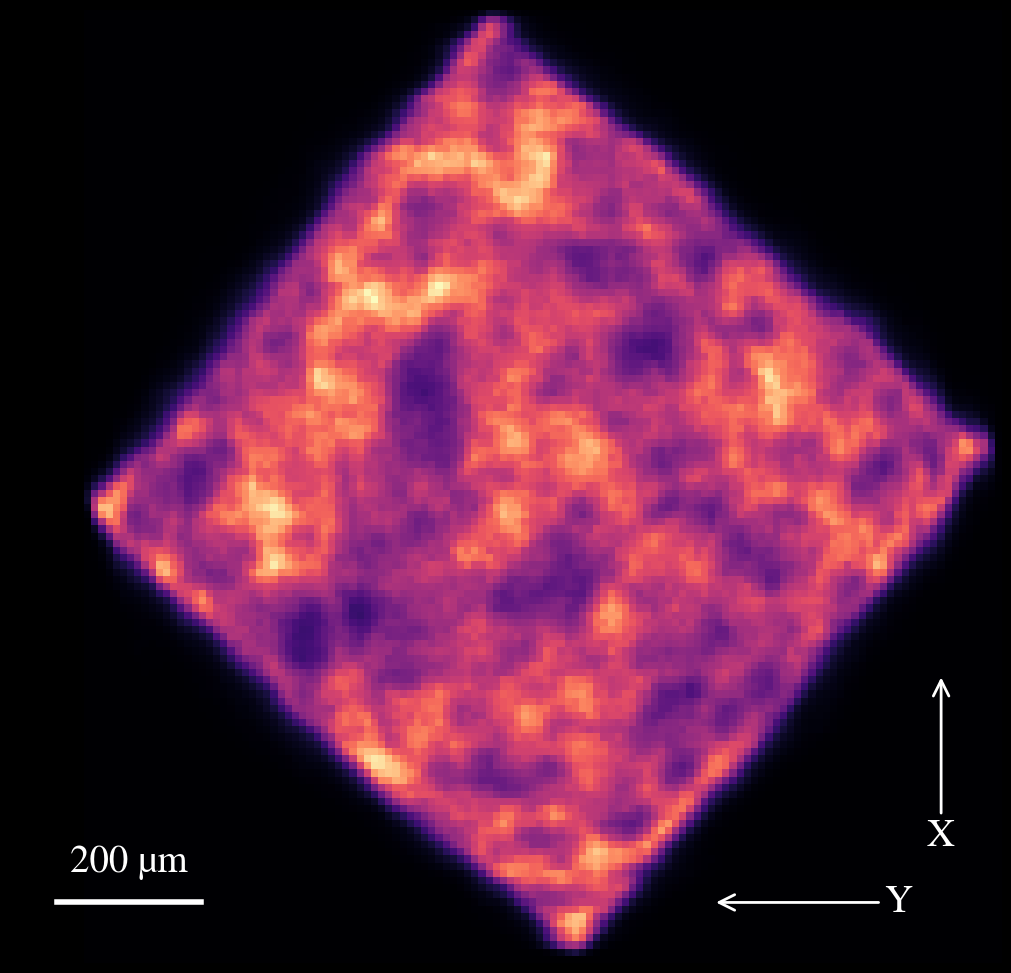

In [8]:
fig, axs = plt.subplots(
    1, 1, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 10)
)


_s = rec.copy()
_s = maptools.plot.crop_to_mask(_s, m)
axs.imshow(_s, vmin=0, origin="lower", cmap="magma")

axs.invert_xaxis()

h, w = rec.shape[:2]
axs.annotate(
    "Y",
    xy=(0.25 * w, 0.05 * h),
    xytext=(0.1 * w, 0.05 * h),
    arrowprops=dict(arrowstyle="->", color="white", lw=2),
    color="white",
    va="center",
)
axs.annotate(
    "X",
    xy=(0.05 * w, 0.25 * h),
    xytext=(0.05 * w, 0.1 * h),
    arrowprops=dict(arrowstyle="->", color="white", lw=2),
    color="white",
    ha="center",
)

px_per_um = 1 / 10
bar_um = 200
bar_px = bar_um * px_per_um
x0 = 0.7 * w
y0 = 0.05 * h
axs.plot([x0, x0 + bar_px], [y0, y0], color="white", lw=4)
axs.text(
    x0 + bar_px / 2,
    y0 + 0.02 * h,
    f"{bar_um} µm",
    color="white",
    ha="center",
    va="bottom",
)

axs.set_axis_off()


In [9]:
ubis = refined_pbpmap.ubi
strain = refined_pbpmap.eps
grains = np.empty((ubis.shape[-1],), dtype=object)
strains = np.empty((ubis.shape[-1],), dtype=object)
for i in range(ubis.shape[-1]):
    ubi = ubis[:, :, i]
    eps = strain[:, :, i]
    grains[i] = ImageD11.grain.grain(ubi)
    grains[i].ref_unitcell = maptools.constants.UNITCELL
    strains[i] = eps

In [10]:
utils.get_rgbs_for_grains(grains)

In [11]:
ipf = np.zeros((len(grains), 3, 3))
ipf[:, :, 0] = np.array([g.rgb_x for g in grains])
ipf[:, :, 1] = np.array([g.rgb_y for g in grains])
ipf[:, :, 2] = np.array([g.rgb_z for g in grains])

In [12]:
kk = np.zeros(m.shape, dtype=np.uint8)
i_shift = refined_pbpmap.i_shift.copy()
j_shift = refined_pbpmap.j_shift.copy()
for ii in range(refined_pbpmap.ubi.shape[-1]):
    kk[i_shift[ii], j_shift[ii]] += 1
nchannels = kk.max()

In [13]:
gmap = np.zeros((*m.shape, nchannels, 3, 3))
rgbmap = np.zeros((*m.shape, nchannels, 3, 3))
unimap = np.zeros((*m.shape, nchannels))
epsmap = np.zeros((*m.shape, nchannels, 3, 3))
kk = np.zeros(m.shape, dtype=np.uint8)
i_shift = refined_pbpmap.i_shift.copy()
j_shift = refined_pbpmap.j_shift.copy()
ubis = refined_pbpmap.ubi.copy()
nuniq = refined_pbpmap.nuniq.copy()
for ii in range(refined_pbpmap.ubi.shape[-1]):
    i, j = i_shift[ii], j_shift[ii]
    gmap[i, j, kk[i, j], :, :] = ubis[:, :, ii]
    unimap[i, j, kk[i, j]] = nuniq[ii]
    rgbmap[i, j, kk[i, j], :, :] = ipf[ii, :, :]
    epsmap[i, j, kk[i, j], :, :] = strains[ii]
    kk[i, j] += 1

index = np.argsort(-unimap, axis=-1)
for i in range(gmap.shape[0]):
    for j in range(gmap.shape[1]):
        unimap[i, j] = unimap[i, j, index[i, j]]
        gmap[i, j, ...] = gmap[i, j, index[i, j], :, :]
        rgbmap[i, j, ...] = rgbmap[i, j, index[i, j], :, :]
        epsmap[i, j, ...] = epsmap[i, j, index[i, j], :, :]

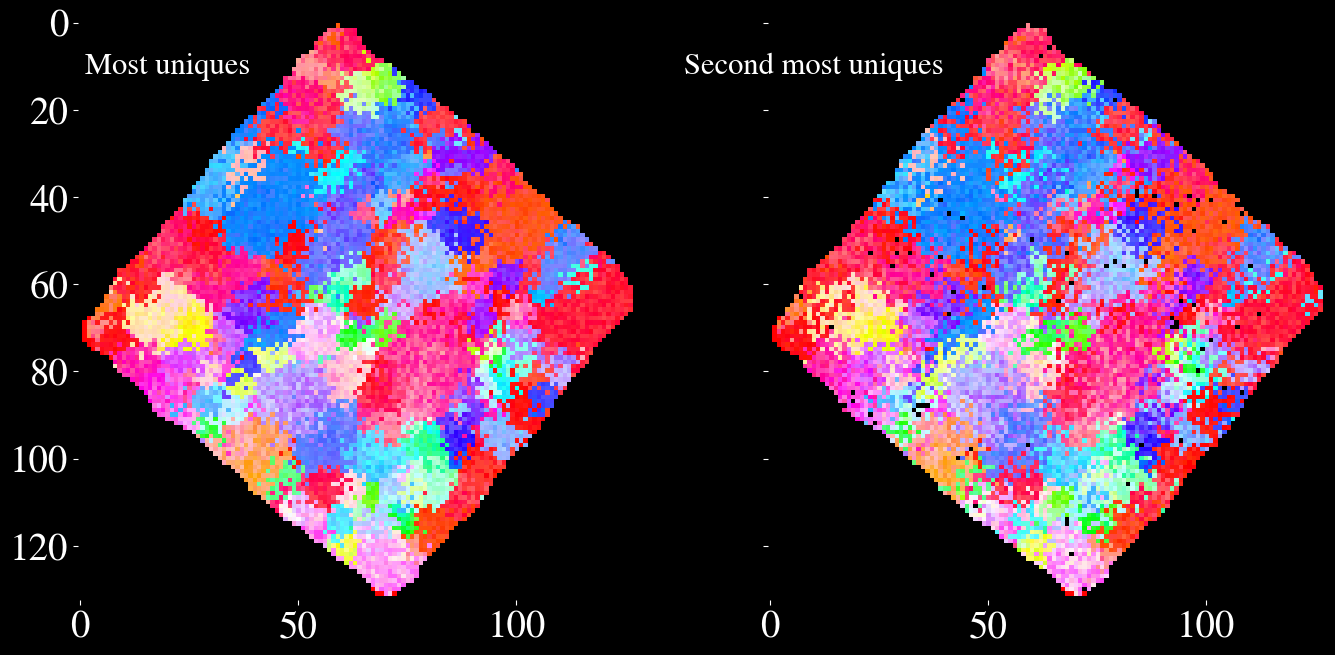

In [14]:
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
_s = rgbmap[:, :, 0, :, 2]
_s[~m] = 0
_s = maptools.plot.crop_to_mask(_s, m)
im = ax[0].imshow(_s)
_s = rgbmap[:, :, 1, :, 2]
_s[~m] = 0
_s = maptools.plot.crop_to_mask(_s, m)
im = ax[1].imshow(_s)

ax[0].text(20, 10, "Most uniques", ha="center", va="center", fontsize=22, color="white")
ax[1].text(
    10, 10, "Second most uniques", ha="center", va="center", fontsize=22, color="white"
)
for a in ax.flatten():
    for spine in a.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
best_rgb = rgbmap[:, :, 0, :, :].astype(float)
best_rgb[~m] = np.nan

rgb_median = np.zeros_like(best_rgb)
for i in range(3):
    for j in range(3):
        rgb_median[:, :, i, j] = generic_filter(
            best_rgb[:, :, i, j],
            function=np.nanmedian,
            size=3,
            mode="constant",
            cval=np.nan,
        )


/zhome/71/c/146676/miniconda3/envs/textom/lib/python3.11/site-packages/scipy/ndimage/_filters.py:2420: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,


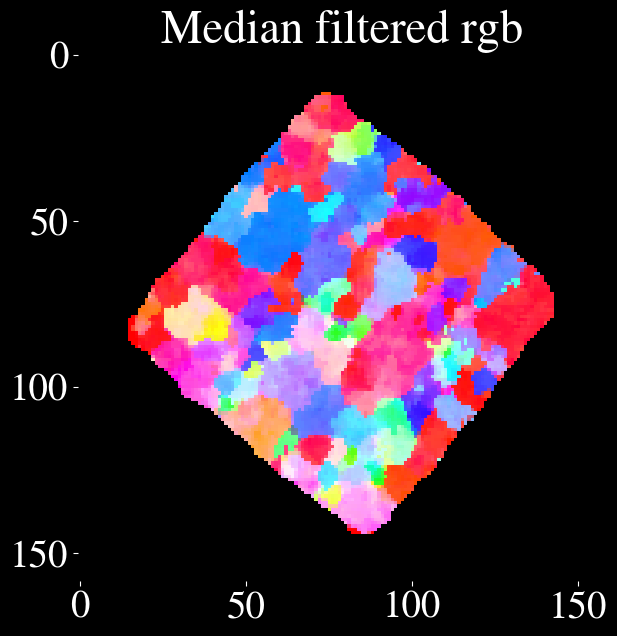

In [16]:
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
im = ax.imshow(rgb_median[..., 2])
ax.set_title("Median filtered rgb")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
index = np.zeros_like(m, dtype=np.uint8)
cost = np.zeros((*m.shape, nchannels), dtype=np.float32)


for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        if m[i, j]:
            for k in range(nchannels):
                drgb = rgb_median[i, j, :, :] - rgbmap[i, j, k, :, :]
                cost[i, j, k] = np.linalg.norm(drgb.flatten())

index = np.argsort(cost, axis=-1)

rgb_filtered = np.take_along_axis(rgbmap, index[..., None, None], axis=2)

ubi_filtered = np.take_along_axis(gmap, index[..., None, None], axis=2)

nuniq_filtered = np.take_along_axis(unimap, index, axis=2)

eps_filtered = np.take_along_axis(epsmap, index[..., None, None], axis=2)

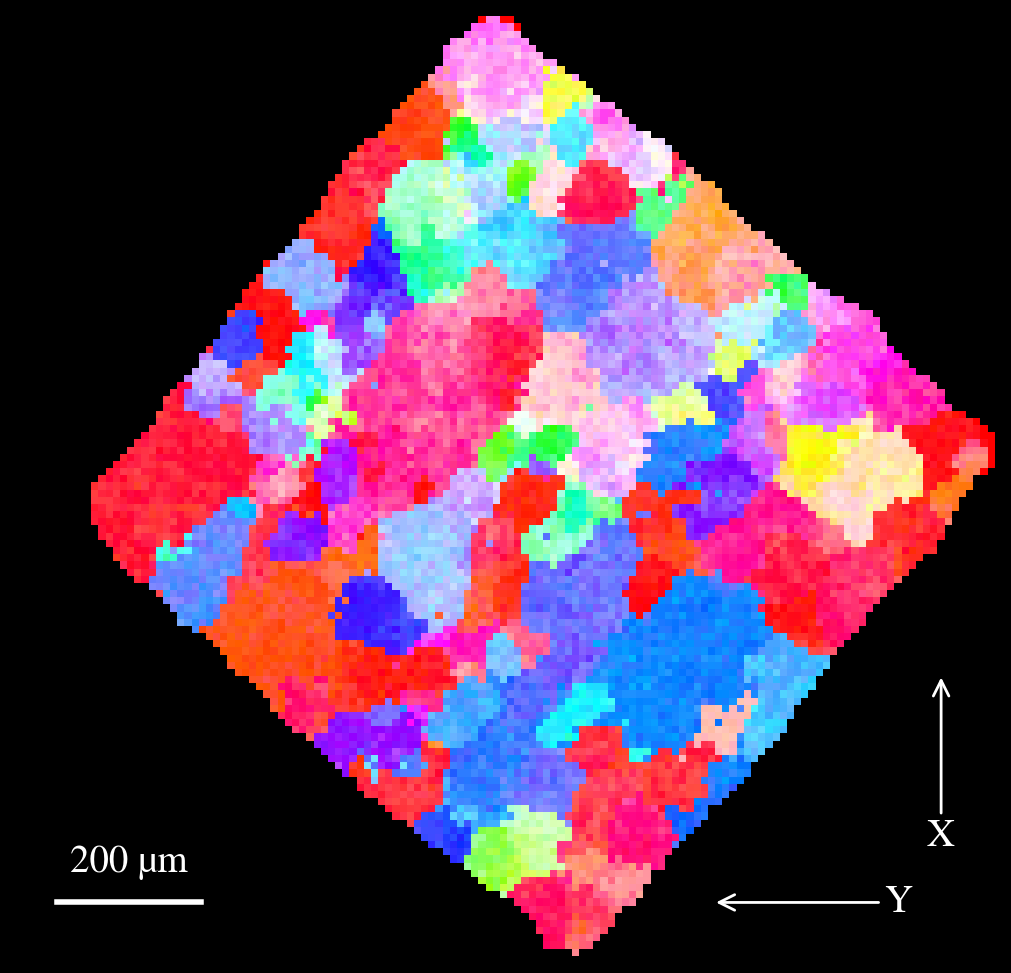

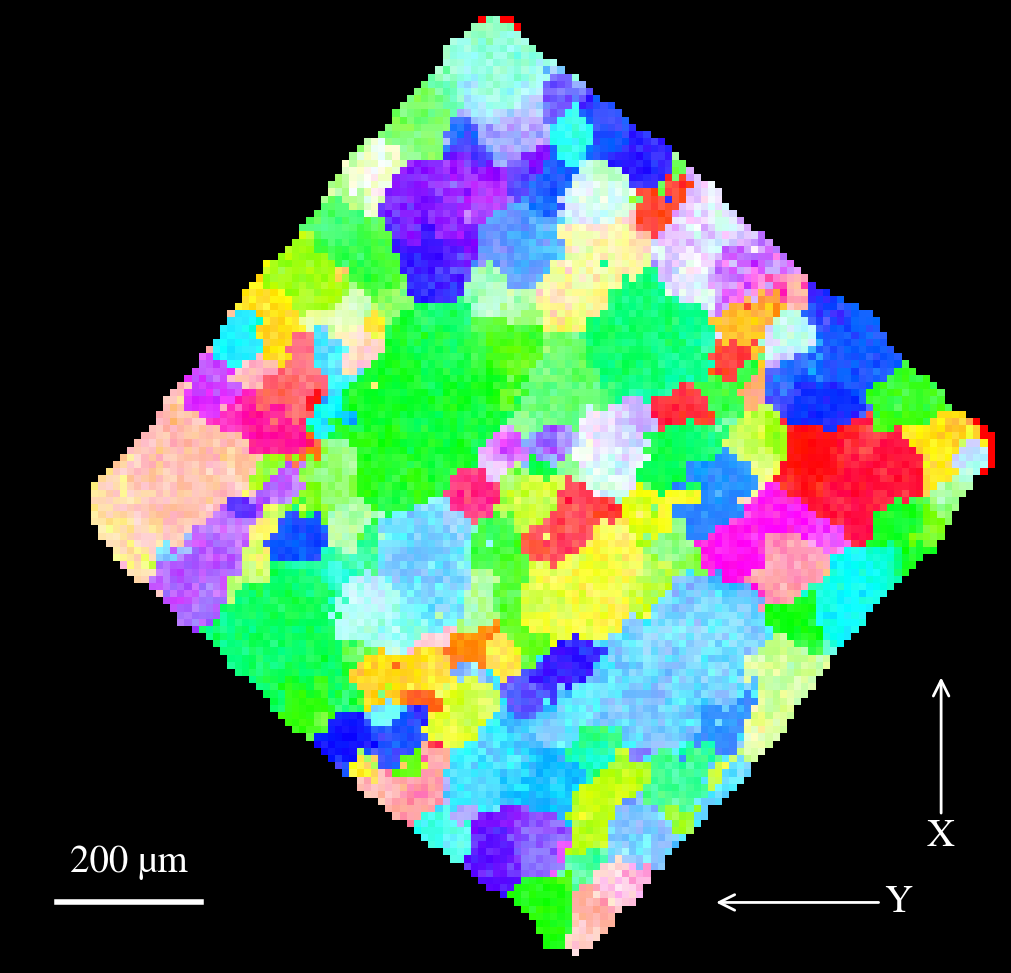

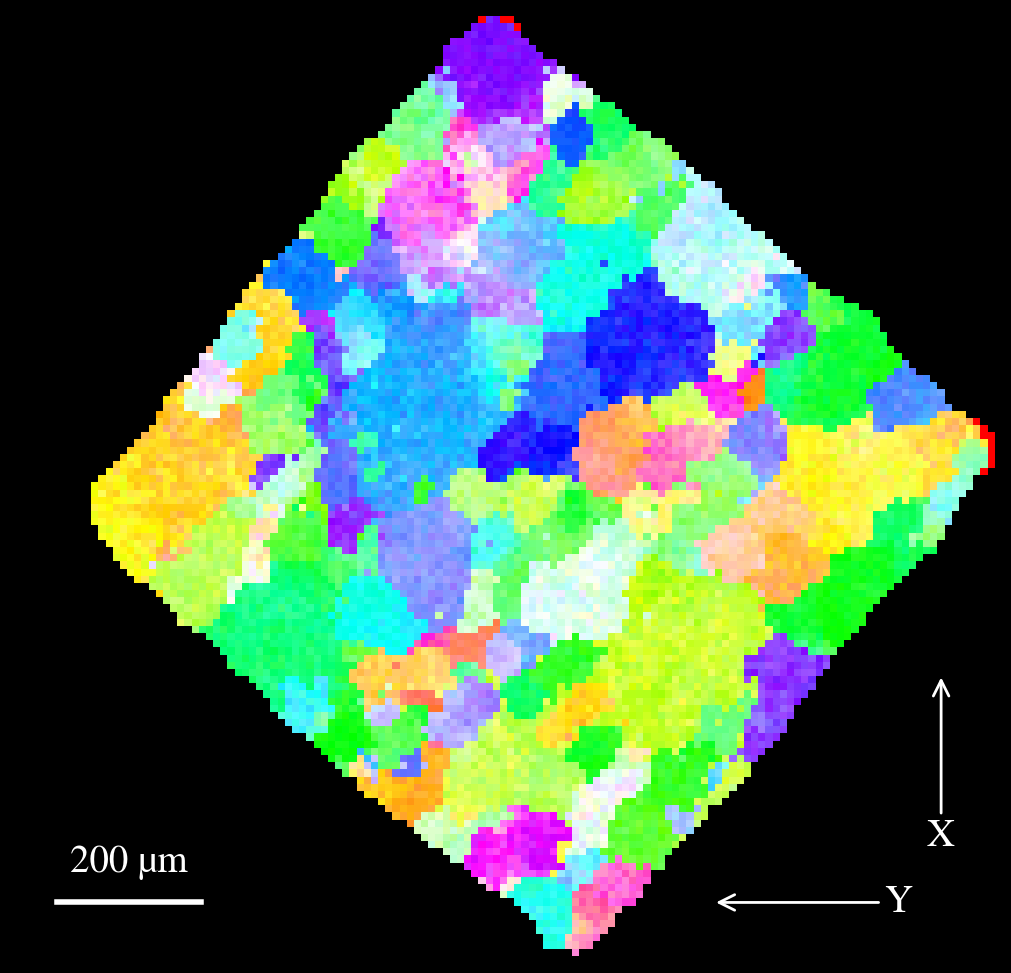

In [18]:
for ii in [2, 1, 0]:
    fig, axs = plt.subplots(
        1, 1, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 10)
    )

    _s = rgb_filtered[:, :, 0, :, ii]

    _s[~m] = np.nan

    _s = maptools.plot.crop_to_mask(_s, m)
    axs.imshow(_s, vmin=0, origin="lower", cmap="magma")

    axs.invert_xaxis()

    h, w = rec.shape[:2]
    axs.annotate(
        "Y",
        xy=(0.25 * w, 0.05 * h),
        xytext=(0.1 * w, 0.05 * h),
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white",
        va="center",
    )
    axs.annotate(
        "X",
        xy=(0.05 * w, 0.25 * h),
        xytext=(0.05 * w, 0.1 * h),
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white",
        ha="center",
    )

    px_per_um = 1 / 10
    bar_um = 200
    bar_px = bar_um * px_per_um
    x0 = 0.7 * w
    y0 = 0.05 * h
    axs.plot([x0, x0 + bar_px], [y0, y0], color="white", lw=4)
    axs.text(
        x0 + bar_px / 2,
        y0 + 0.02 * h,
        f"{bar_um} µm",
        color="white",
        ha="center",
        va="bottom",
    )

    axs.set_axis_off()


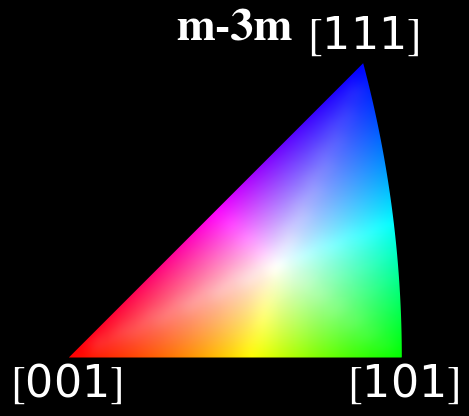

In [19]:
ck = plot.IPFColorKeyTSL(Oh, direction=Vector3d.zvector())  # IPF-Z
ck.plot()
plt.show()


In [20]:
ubi_filtered[:, :, 0, :, :].shape
orix_orien = []
for i in range(ubi_filtered.shape[0]):
    for j in range(ubi_filtered.shape[1]):
        if m[i, j]:
            g = ImageD11.grain.grain(ubi_filtered[i, j, 0, :, :])
            g.ref_unitcell = maptools.constants.UNITCELL
            orix_orien.append(g.orix_orien)
orix_orien = Orientation.stack(orix_orien)

ValueError: Number of given colors 1 do not match number of vectors 8960

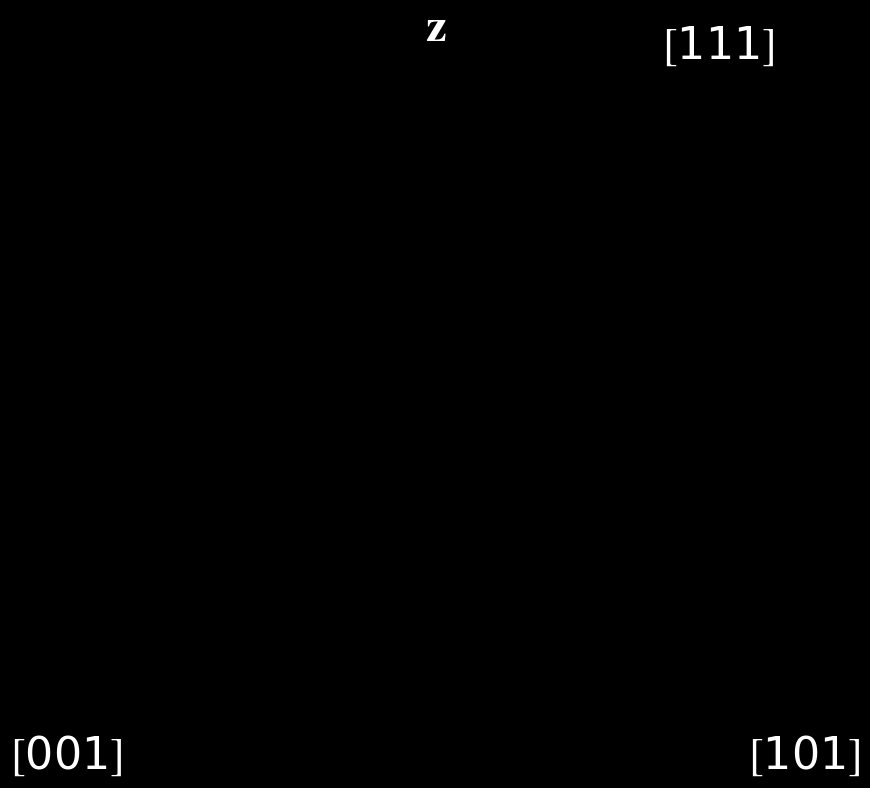

In [21]:
plt.rcParams["axes.grid"] = False

for vec in [Vector3d.zvector(), Vector3d.yvector(), Vector3d.xvector()]:
    ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=vec)
    orix_orien.symmetry = ipfkey.symmetry
    rgb_z = ipfkey.orientation2color(orix_orien)
    orix_orien.scatter(
        "ipf",
        c=rgb_z,
        direction=ipfkey.direction,
        s=0.75,
        figure_kwargs={"figsize": (10, 10)},
    )

    ax = plt.gca()

    for p in ax.patches:
        p.set_edgecolor("white")
        p.set_linewidth(1.2)

    for l in ax.lines:
        l.set_color("white")
        l.set_linewidth(1.2)

In [ ]:
footprint = np.array(
    [
        [
            0,
            1,
            0,
        ],
        [
            1,
            1,
            1,
        ],
        [
            0,
            1,
            0,
        ],
    ]
)
sample_mask = m.copy()
refined_ubi_map_remapped = ubi_filtered[:, :, 0, :, :].copy()
orientation_map = maptools.properties.get_u_map(refined_ubi_map_remapped, sample_mask)

kam = maptools.properties.kernel_average_misorientation(
    orientation_map,
    footprint=footprint,
    crystal_system=7,
    misorientation_threshold=(0, np.inf),
    mask=sample_mask,
    fill_value=np.nan,
)


  0%|          | 0/157 [00:00<?, ?it/s]

In [ ]:
savepath = os.path.join(
    maptools.paths.PROCESS, "al1050_15pct_center_slice", "reconstructions"
)

data = {
    "orientation_orix": orix_orien,
    "grains_raw": grains,
    "filter_index": index,
    "rgb_map_filtered": rgb_filtered,
    "ubi_map_filtered": ubi_filtered,
    "nuniq_map_filtered": nuniq_filtered,
    "strain_map_filtered": eps_filtered,
    "g_map_raw": gmap,
    "rgb_map_raw": rgbmap,
    "uniqueness_map_raw": unimap,
    "strain_map_raw": epsmap,
    "orientation_map_filtered": orientation_map,
    "kam_map_filtered": kam,
    "sample_mask": m,
    "reconstruction_mlem": rec,
}

maptools.io.save_analysis_bundle(data, savepath, filetag)

'/data/visitors/danmax/20251117/2025110808/process/al1050_15pct_center_slice/reconstructions/medium_pks_18M_2025_1213_095603'